<a href="https://colab.research.google.com/github/CliffAD/CAD-Projects/blob/main/Machine_learning_Project_Cardiovascular_Disease_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
## CLIFFORD ANTHONY DSOUZA - BACHELOR'S STEM PROGRAM GERMAN TRACK
## DATA 110 - MACHINE LEARNING PROJECT PROPOSAL
## Enhanced Predictive Modelling for Cardiovascular Disease Diagnosis Using Ensemble Learning and Explainable AI

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


In [ ]:
import pandas as pd
# 1. Data Loading
df = pd.read_csv("/content/heart.csv")

In [ ]:
print("--- Missing Values (Count) ---")
print(df.isnull().sum())

--- Missing Values (Count) ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [ ]:
import warnings
warnings.filterwarnings('ignore')
# To reset warnings to default behavior:
# warnings.filterwarnings('default')

In [ ]:
import pandas as pd
import os

file_path = "/heart.csv"

if not os.path.exists(file_path):
    print(f"Error: The file '{file_path}' was not found.")
    print("Please ensure 'heart.csv' is uploaded to the '/content/' directory.")
    print("You can upload it by clicking the 'Files' icon on the left sidebar, then 'Upload'.")
else:
    # Load the dataset
    df = pd.read_csv(file_path)

    # Display descriptive statistics
    print("\n--- Descriptive Statistics ---")
    print(df.describe())


--- Descriptive Statistics ---
               age          sex           cp     trestbps        chol  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.00000   
mean     54.434146     0.695610     0.942439   131.611707   246.00000   
std       9.072290     0.460373     1.029641    17.516718    51.59251   
min      29.000000     0.000000     0.000000    94.000000   126.00000   
25%      48.000000     0.000000     0.000000   120.000000   211.00000   
50%      56.000000     1.000000     1.000000   130.000000   240.00000   
75%      61.000000     1.000000     2.000000   140.000000   275.00000   
max      77.000000     1.000000     3.000000   200.000000   564.00000   

               fbs      restecg      thalach        exang      oldpeak  \
count  1025.000000  1025.000000  1025.000000  1025.000000  1025.000000   
mean      0.149268     0.529756   149.114146     0.336585     1.071512   
std       0.356527     0.527878    23.005724     0.472772     1.175053   
min       0.00

In [ ]:
## Interpretation of EDA
# 1.	Data Structure: The dataset contains 1025 entries and 14 columns with no missing values (isnull().sum() returned 0 for all columns), simplifying the preprocessing stage. Data types are a mix of integers and floats.


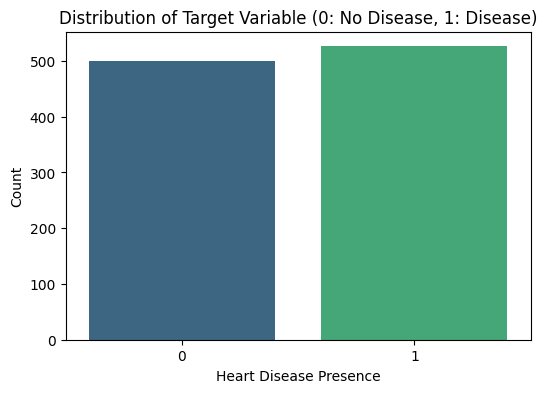

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 5. Data Visualization

# A. Target Variable Distribution (Checking Balance)
plt.figure(figsize=(6, 4))
sns.countplot(x='target', data=df, palette='viridis')
plt.title('Distribution of Target Variable (0: No Disease, 1: Disease)')
plt.xlabel('Heart Disease Presence')
plt.ylabel('Count')
plt.show()

In [ ]:
## Interpretation of EDA
# 2.	Target Distribution: The count plot shows a relatively balanced dataset, with slightly more patients diagnosed with heart disease (Target=1) than those without. This reduces the immediate need for aggressive resampling, though SMOTE may still be used to refine boundaries.

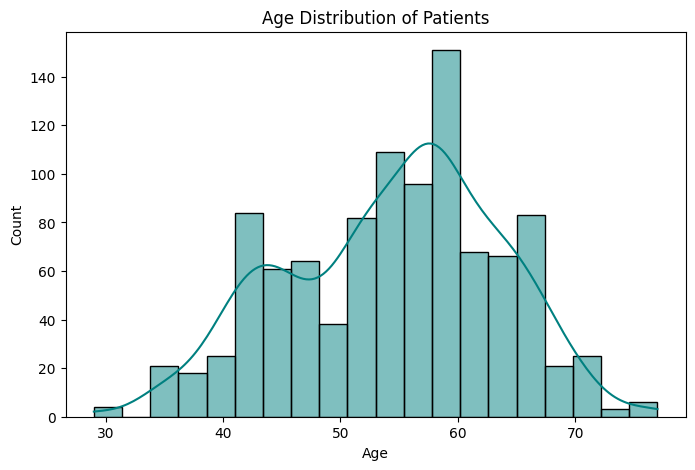

In [ ]:
# B. Histogram for Age Distribution
plt.figure(figsize=(8, 5))
sns.histplot(df['age'], bins=20, kde=True, color='teal')
plt.title('Age Distribution of Patients')
plt.xlabel('Age')
plt.show()


In [ ]:
## Interpretation of EDA
# 3.	Descriptive Statistics: The average age of patients is approximately 54 years. The cholesterol levels show a wide range (126 - 564 mg/dl), indicating the presence of potential outliers, which were visualized in the box plot.

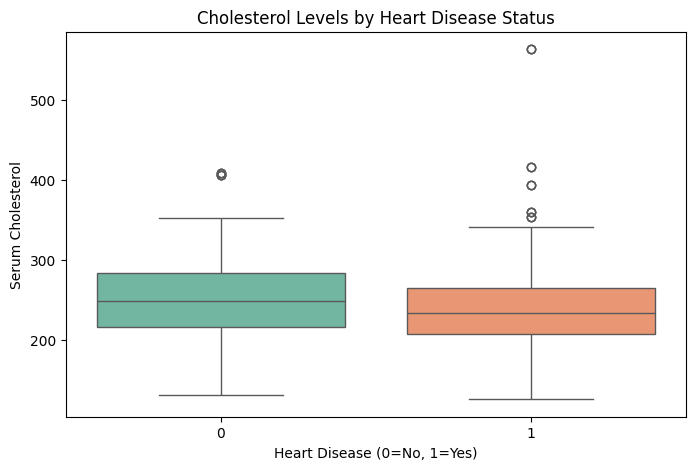

In [ ]:
# C. Box Plots for Outlier Detection (Cholesterol vs Target)
plt.figure(figsize=(8, 5))
sns.boxplot(x='target', y='chol', data=df, palette='Set2')
plt.title('Cholesterol Levels by Heart Disease Status')
plt.xlabel('Heart Disease (0=No, 1=Yes)')
plt.ylabel('Serum Cholesterol')
plt.show()


In [ ]:
## Interpretation of EDA
# 4.	Correlation Analysis: The heatmap reveals that cp (Chest Pain type), thalach (Max Heart Rate), and slope have positive correlations with the target, while exang (Exercise Induced Angina) and oldpeak have negative correlations. This confirms that these features are strong predictors.

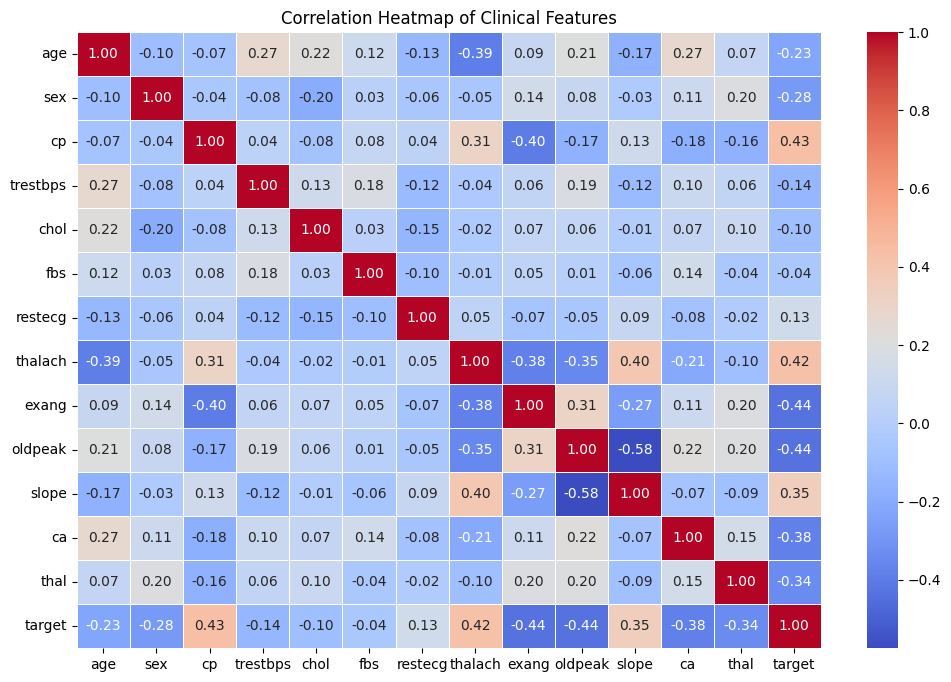

In [ ]:
# D. Correlation Heatmap
plt.figure(figsize=(12, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Clinical Features')
plt.show()


In [ ]:
## Interpretation of EDA
# 5.	Outliers: The box plot for cholesterol indicates several high-value outliers. These outliers are clinically significant (extremely high cholesterol is a risk factor) and should not be dropped arbitrarily; instead, robust scaling techniques will be used during modelling.

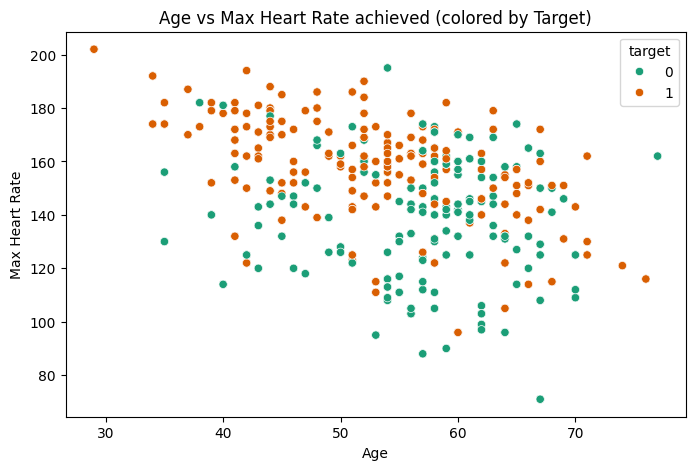

In [ ]:
# E. Scatter Plot: Age vs Max Heart Rate
plt.figure(figsize=(8, 5))
sns.scatterplot(x='age', y='thalach', hue='target', data=df, palette='Dark2')
plt.title('Age vs Max Heart Rate achieved (colored by Target)')
plt.xlabel('Age')
plt.ylabel('Max Heart Rate')
plt.show()
